# Time Series Benchmark: Causal vs Traditional Models

This notebook evaluates causal vs traditional ML models on time series data generated from a known Structural Causal Model (SCM) defined in `A2C.ipynb`.

**Two evaluation tables are produced:**
1. **Test set** — standard forecasting accuracy (observational data)
2. **Intervention** — prediction accuracy under multiple do-interventions

**DGP Configuration:** `n_vars=4, max_lag=2, gaussian noise`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from scipy import stats

import utils as ut

current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
print("Setup complete.")

Setup complete.


## 1. Data Generating Process (from A2C)

We copy the core DGP functions from the A2C notebook so this notebook is self-contained.

In [2]:
# ============================================================
# DGP: Time Series Generator (from A2C.ipynb)
# ============================================================

def get_linear_equations(n_vars, max_lag):
    """Get linear equations for specified configuration with confounder"""
    if n_vars == 4:
        if max_lag == 2:
            return [
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 3:
            return [
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 4:
            return [
                "X4[t] = 0.25 * X1[t-4] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
    return []


def extract_causal_links(equations):
    """Extract causal links: {(source, lag, target): coefficient}"""
    causal_links = {}
    for eq in equations:
        if '=' not in eq:
            continue
        left, right = [side.strip() for side in eq.split('=')]
        target = left.split('[')[0]
        # Skip pure noise equations (e.g., "U[t] = eU") 
        if right.startswith('e'):
            continue
        terms = [term.strip() for term in right.replace('- ', '+ -').split('+')]
        for term in terms:
            term = term.strip()
            if '*' in term:
                coeff, var_part = [p.strip() for p in term.split('*')]
                var = var_part.split('[')[0]
                if var.startswith('e'):
                    continue
                lag_part = var_part.split('[')[1].split(']')[0]
                lag = 0 if lag_part == 't' else int(lag_part.split('-')[1])
                causal_links[(var, lag, target)] = float(coeff)
    return causal_links


class TimeSeriesGenerator:
    def __init__(self, noise_scale=0.1, random_state=None):
        self.noise_scale = noise_scale
        self.random_state = random_state

    def generate_noise(self, size):
        return np.random.normal(0, self.noise_scale, size=size)

    def generate(self, n_points, n_vars, max_lag):
        """Generate multivariate time series from the SCM."""
        if self.random_state is not None:
            np.random.seed(self.random_state)

        equations = get_linear_equations(n_vars, max_lag)
        causal_links = extract_causal_links(equations)

        X = np.zeros((n_points, n_vars))
        U = np.zeros(n_points)

        # Initialize with noise
        for i in range(max_lag):
            X[i] = self.generate_noise(n_vars)
            U[i] = self.generate_noise(1)[0]

        # Generate time series step by step
        for t in range(max_lag, n_points):
            noise = self.generate_noise(n_vars + 1)
            U[t] = noise[-1]  # Confounder is pure noise

            for i in range(n_vars):
                var_name = f'X{i+1}'
                value = 0
                has_parents = False
                for (source, lag, target), coef in causal_links.items():
                    if target == var_name:
                        has_parents = True
                        if source == 'U':
                            value += coef * U[t]
                        else:
                            source_idx = int(source[1:]) - 1
                            value += coef * X[t - lag, source_idx]
                if has_parents:
                    X[t, i] = value + noise[i]
                else:
                    X[t, i] = noise[i]  # Exogenous variable

        columns = [f'X{i+1}' for i in range(n_vars)] + ['U']
        df = pd.DataFrame(np.column_stack([X, U]), columns=columns)
        return df

print("DGP functions defined.")

DGP functions defined.


## 2. Configuration & Data Generation

In [3]:
# ============================================================
# Configuration
# ============================================================
N_POINTS = 1000
N_VARS = 4
MAX_LAG = 2
TRAIN_RATIO = 0.8
RANDOM_STATE = 42
TARGET_VAR = 'X4'  # deepest downstream variable

# Multiple interventions: (variable_to_intervene, label)
INTERVENTIONS = [
    #{'var': 'X1', 'shift': 2.0,  'label': 'do(X1 = μ + 2σ)'},
    {'var': 'X1', 'shift': -2.0, 'label': 'do(X1 = μ − 2σ)'}
    #{'var': 'X1', 'shift': 0, 'label': 'do(X1 = μ − 2σ)'},
    #{'var': 'X1', 'shift': None, 'label': 'do(X1 = X1) [identity]'},
    #{'var': 'X2', 'shift': 2.0,  'label': 'do(X2 = μ + 2σ)'},
    #{'var': 'X3', 'shift': 2.0,  'label': 'do(X3 = μ + 2σ)'},
]

# Generate data
generator = TimeSeriesGenerator(noise_scale=0.1, random_state=RANDOM_STATE)
df_full = generator.generate(n_points=N_POINTS, n_vars=N_VARS, max_lag=MAX_LAG)

print(f"Generated time series: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")
print(f"\nFirst 5 rows:")
df_full.head()

Generated time series: (1000, 5)
Columns: ['X1', 'X2', 'X3', 'X4', 'U']

First 5 rows:


,X1,X2,X3,X4,U
0,0.049671,-0.013826,0.064769,0.152303,-0.023415
1,-0.023414,0.157921,0.076743,-0.046947,0.054256
2,-0.132588,-0.023550,-0.027551,-0.178910,-0.172492
3,-0.126844,-0.109549,-0.010944,-0.096656,-0.141230
4,0.119346,-0.025861,-0.009579,-0.175622,-0.054438


## 3. Feature Engineering: Lagged Features

In [4]:
def create_lagged_features(df, max_lag, var_columns):
    """
    Create lagged feature columns for each variable.
    
    For each variable Xi, creates Xi_lag1, Xi_lag2, ..., Xi_lagK.
    Also keeps the contemporaneous values (lag 0) as Xi_lag0.
    Drops rows with NaNs from lagging.
    
    Returns:
        df_lagged: DataFrame with all lagged features
    """
    df_lagged = pd.DataFrame(index=df.index)
    
    for col in var_columns:
        # Contemporaneous value (lag 0)
        df_lagged[f'{col}_lag0'] = df[col]
        # Lagged values
        for lag in range(1, max_lag + 1):
            df_lagged[f'{col}_lag{lag}'] = df[col].shift(lag)
    
    # Drop rows with NaNs (first max_lag rows)
    df_lagged = df_lagged.dropna().reset_index(drop=True)
    return df_lagged


# All variables including U
all_vars = [f'X{i+1}' for i in range(N_VARS)] + ['U']

# Create lagged features
df_lagged = create_lagged_features(df_full, MAX_LAG, all_vars)

print(f"Lagged dataset shape: {df_lagged.shape}")
print(f"Columns: {list(df_lagged.columns)}")
df_lagged.head()

Lagged dataset shape: (998, 15)
Columns: ['X1_lag0', 'X1_lag1', 'X1_lag2', 'X2_lag0', 'X2_lag1', 'X2_lag2', 'X3_lag0', 'X3_lag1', 'X3_lag2', 'X4_lag0', 'X4_lag1', 'X4_lag2', 'U_lag0', 'U_lag1', 'U_lag2']


,X1_lag0,X1_lag1,X1_lag2,X2_lag0,X2_lag1,X2_lag2,X3_lag0,X3_lag1,X3_lag2,X4_lag0,X4_lag1,X4_lag2,U_lag0,U_lag1,U_lag2
0,-0.132588,-0.023414,0.049671,-0.023550,0.157921,-0.013826,-0.027551,0.076743,0.064769,-0.178910,-0.046947,0.152303,-0.172492,0.054256,-0.023415
1,-0.126844,-0.132588,-0.023414,-0.109549,-0.023550,0.157921,-0.010944,-0.027551,0.076743,-0.096656,-0.178910,-0.046947,-0.141230,-0.172492,0.054256
2,0.119346,-0.126844,-0.132588,-0.025861,-0.109549,-0.023550,-0.009579,-0.010944,-0.027551,-0.175622,-0.096656,-0.178910,-0.054438,-0.141230,-0.172492
3,-0.003492,0.119346,-0.126844,-0.117973,-0.025861,-0.109549,0.028819,-0.009579,-0.010944,-0.091775,-0.175622,-0.096656,-0.029169,-0.054438,-0.141230
4,-0.019043,-0.003492,0.119346,0.193874,-0.117973,-0.025861,0.023327,0.028819,-0.009579,-0.075935,-0.091775,-0.175622,0.082254,-0.029169,-0.054438


## 4. Build Causal Graph with Lagged Edges

In [5]:
def build_lagged_causal_graph(n_vars, max_lag):
    """
    Build a DAG over flattened lagged features using the known SCM equations.
    
    Each node in the graph is a lagged feature like 'X1_lag0', 'X3_lag1', etc.
    Edges represent the causal relationships from the SCM.
    
    Returns:
        G: nx.DiGraph
        parent_map: dict mapping each target node to its list of parent feature names
    """
    equations = get_linear_equations(n_vars, max_lag)
    causal_links = extract_causal_links(equations)
    
    G = nx.DiGraph()
    parent_map = {}  # {target_lag0: [parent_features]}
    
    for (source, lag, target), coef in causal_links.items():
        source_feature = f'{source}_lag{lag}'
        target_feature = f'{target}_lag0'  # target is always at current time
        G.add_edge(source_feature, target_feature)
        
        if target_feature not in parent_map:
            parent_map[target_feature] = []
        parent_map[target_feature].append(source_feature)
    
    return G, parent_map


G, parent_map = build_lagged_causal_graph(N_VARS, MAX_LAG)

print("Causal Graph Edges:")
for edge in G.edges():
    print(f"  {edge[0]} → {edge[1]}")

print(f"\nParent map (features used by causal models):")
for target, parents in parent_map.items():
    print(f"  {target}: {parents}")

Causal Graph Edges:
  X1_lag2 → X4_lag0
  X4_lag0 → X3_lag0
  U_lag0 → X3_lag0
  U_lag0 → X1_lag0
  X3_lag1 → X2_lag0
  X2_lag0 → X1_lag0

Parent map (features used by causal models):
  X4_lag0: ['X1_lag2']
  X3_lag0: ['X4_lag0', 'U_lag0']
  X2_lag0: ['X3_lag1']
  X1_lag0: ['X2_lag0', 'U_lag0']


## 5. Train/Test Split (Chronological)

In [6]:
# Chronological split
split_idx = int(len(df_lagged) * TRAIN_RATIO)
train_df = df_lagged.iloc[:split_idx].reset_index(drop=True)
test_df = df_lagged.iloc[split_idx:].reset_index(drop=True)

# Also split the raw data for intervention generation later
raw_split_idx = int(len(df_full) * TRAIN_RATIO)
test_df_raw = df_full.iloc[raw_split_idx:].reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")

# Target column (contemporaneous, lag 0)
target_col = f'{TARGET_VAR}_lag0'
print(f"\nTarget column: {target_col}")

Train size: 798
Test size:  200

Target column: X4_lag0


## 5b. Visualization: Train/Test Split

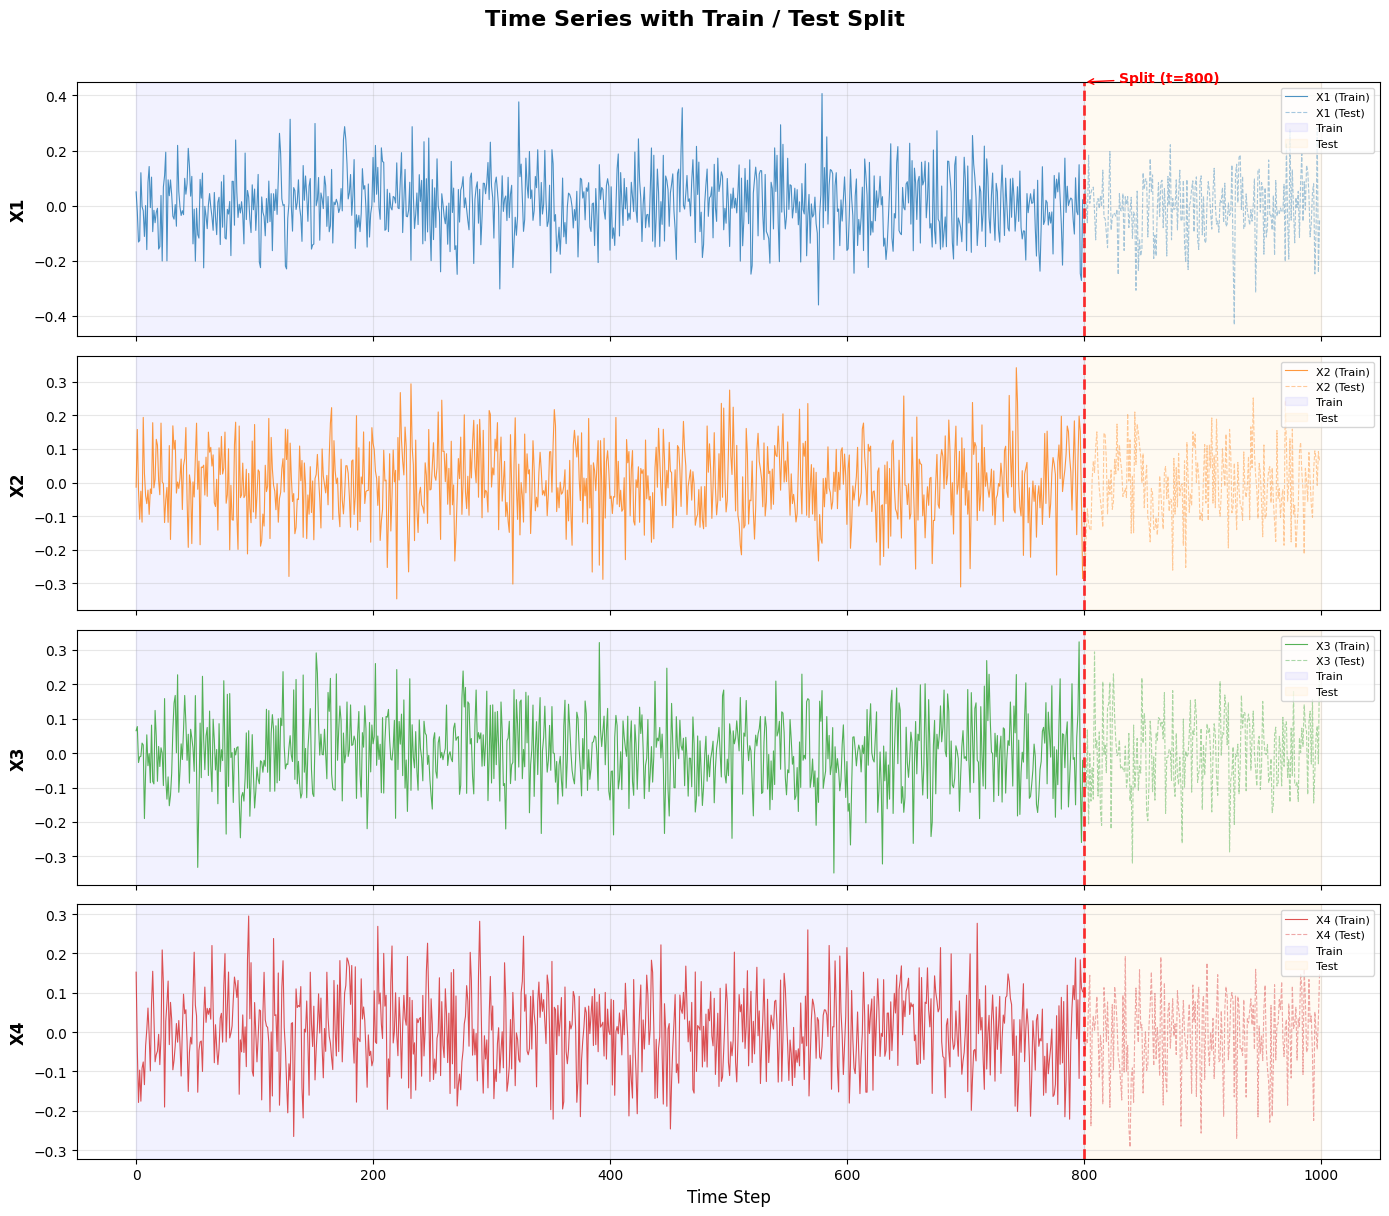


Train: t=0 to t=799 (800 points)
Test:  t=800 to t=999 (200 points)


In [7]:
# ============================================================
# VISUAL 1: Time series with train/test partition
# ============================================================
fig, axes = plt.subplots(N_VARS, 1, figsize=(14, 3 * N_VARS), sharex=True)
fig.suptitle('Time Series with Train / Test Split', fontsize=16, fontweight='bold', y=1.01)

colors = plt.cm.tab10.colors
time_idx = np.arange(len(df_full))

for i in range(N_VARS):
    ax = axes[i]
    var = f'X{i+1}'
    
    # Plot train portion
    ax.plot(time_idx[:raw_split_idx], df_full[var].iloc[:raw_split_idx],
            color=colors[i], alpha=0.8, linewidth=0.8, label=f'{var} (Train)')
    
    # Plot test portion
    ax.plot(time_idx[raw_split_idx:], df_full[var].iloc[raw_split_idx:],
            color=colors[i], alpha=0.4, linewidth=0.8, linestyle='--', label=f'{var} (Test)')
    
    # Partition line
    ax.axvline(x=raw_split_idx, color='red', linestyle='--', linewidth=2, alpha=0.8)
    
    # Shade regions
    ax.axvspan(0, raw_split_idx, alpha=0.05, color='blue', label='Train')
    ax.axvspan(raw_split_idx, len(df_full), alpha=0.05, color='orange', label='Test')
    
    ax.set_ylabel(var, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step', fontsize=12)

# Add annotation for split point
axes[0].annotate(f'Split (t={raw_split_idx})', xy=(raw_split_idx, axes[0].get_ylim()[1]),
                 xytext=(raw_split_idx + 30, axes[0].get_ylim()[1]),
                 fontsize=10, color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print(f"\nTrain: t=0 to t={raw_split_idx-1} ({raw_split_idx} points)")
print(f"Test:  t={raw_split_idx} to t={len(df_full)-1} ({len(df_full) - raw_split_idx} points)")

## 6. Model Definitions (No Hyperparameter Tuning)

In [8]:
# Models with default hyperparameters (no tuning)
model_configs = {
    "RandomForest": {
        "class": RandomForestRegressor,
        "params": {"n_estimators": 200, "max_depth": 10, "random_state": 42}
    },
    "LinearRegression": {
        "class": LinearRegression,
        "params": {}
    },
    "MLP": {
        "class": MLPRegressor,
        "params": {"hidden_layer_sizes": (100, 50), "max_iter": 1000, "random_state": 42}
    },
    "XGBoost": {
        "class": XGBRegressor,
        "params": {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,
                   "random_state": 42, "verbosity": 0}
    },
    "GAM": {
        "class": None,  # handled separately
        "params": {}
    },
}

print(f"Models to evaluate: {list(model_configs.keys())}")

Models to evaluate: ['RandomForest', 'LinearRegression', 'MLP', 'XGBoost', 'GAM']


## 7. Training & Evaluation Functions

In [9]:
def get_traditional_features(df_lagged, target_col):
    """
    For traditional models: use ALL lagged features (excluding the target itself).
    """
    feature_cols = [c for c in df_lagged.columns if c != target_col]
    return feature_cols


def get_causal_features(parent_map, target_col):
    """
    For causal models: use ONLY the parent features from the known causal graph.
    """
    if target_col in parent_map:
        return parent_map[target_col]
    return []


def fit_gam(X_train, y_train):
    """Fit a GAM model."""
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.values
    n_features = X_train.shape[1]
    formula = s(0)
    for i in range(1, n_features):
        formula = formula + s(i)
    model = LinearGAM(formula, max_iter=5000)
    model.fit(X_train, y_train)
    return model


def predict_gam(model, X_test):
    """Predict with a GAM model."""
    if isinstance(X_test, pd.DataFrame):
        X_test = X_test.values
    return model.predict(X_test)


def fit_model(name, cfg, X_train, y_train):
    """Fit a model given its config."""
    if name == "GAM":
        return fit_gam(X_train, y_train)
    else:
        model = cfg["class"](**cfg["params"])
        if isinstance(X_train, pd.DataFrame):
            model.fit(X_train.values, y_train.values)
        else:
            model.fit(X_train, y_train)
        return model


def predict_model(name, model, X_test):
    """Predict with a model."""
    if name == "GAM":
        return predict_gam(model, X_test)
    else:
        if isinstance(X_test, pd.DataFrame):
            return model.predict(X_test.values)
        return model.predict(X_test)


def evaluate_metrics(y_true, y_pred):
    """Compute MAE, RMSE, WAPE."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = 100.0 * np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10)
    return mae, rmse, wape


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 8. Causal Model Training (Per-Node)

For the **causal** approach, we train a separate model for each node (variable at lag 0) that has parents in the causal graph. This mirrors the structure of `003_benchmark.ipynb`'s causal pipeline, but using lagged features.

In [10]:
def train_causal_models_ts(train_df, parent_map, model_name, model_cfg):
    """
    Train one model per node in the causal graph.
    Each model predicts a node from its known causal parents.
    
    Returns:
        dict: {node_name: trained_model}
    """
    causal_models = {}
    for node, parents in parent_map.items():
        if not parents:
            continue
        X = train_df[parents]
        y = train_df[node]
        model = fit_model(model_name, model_cfg, X, y)
        causal_models[node] = model
    return causal_models


def predict_causal_ts(df, parent_map, causal_models, model_name, what_if=False):
    """
    Predict using causal models.
    
    If what_if=False: use observed parent values (test evaluation).
    If what_if=True: propagate predictions forward through the graph 
                     (intervention evaluation - use predicted upstream values).
    
    Returns:
        pd.DataFrame with predictions for all nodes
    """
    preds = pd.DataFrame(index=df.index)
    
    if what_if:
        # Copy all features (including lagged ones which are "observed")
        working_df = df.copy()
        
        # Predict in topological order of the causal graph
        predicted_nodes = set()
        remaining = dict(parent_map)
        
        # Keep iterating until all nodes are predicted
        max_iter = len(remaining) + 1
        for _ in range(max_iter):
            if not remaining:
                break
            for node, parents in list(remaining.items()):
                # Check if all parent nodes (at lag 0) have been predicted
                # Parents at lag > 0 are already in the data (observed)
                lag0_parents = [p for p in parents if p.endswith('_lag0')]
                lag0_parents_predicted = all(
                    p in predicted_nodes or p not in parent_map 
                    for p in lag0_parents
                )
                
                if lag0_parents_predicted:
                    X_pred = working_df[parents]
                    model = causal_models[node]
                    prediction = predict_model(model_name, model, X_pred)
                    preds[node] = prediction
                    working_df[node] = prediction  # Update for downstream nodes
                    predicted_nodes.add(node)
                    del remaining[node]
    else:
        # Standard test evaluation: use observed parent values
        for node, parents in parent_map.items():
            if node in causal_models:
                X_pred = df[parents]
                model = causal_models[node]
                preds[node] = predict_model(model_name, model, X_pred)
    
    return preds


print("Causal model training functions defined.")

Causal model training functions defined.


## 9. Multiple Intervention Data Generation

We simulate **multiple do-interventions**: for each, we force a variable to a fixed value and regenerate all downstream variables using the true SCM equations. This tests whether causal models generalize better than traditional models under distributional shifts.

In [11]:
def generate_intervention_data(test_df_raw, n_vars, max_lag, intervene_var, intervene_value):
    """
    Generate intervention (ground truth) data by:
    1. Taking the raw test time series
    2. Extracting the original noise terms (noise = observed - structural)
    3. Setting `intervene_var` to `intervene_value` (do-operation)
    4. Recomputing all downstream variables using the true SCM + original noise
    
    This preserves the original noise so the ONLY difference is the intervention.
    With shift=0, the output should match the observational data exactly.
    
    Returns:
        df_intervened: Raw DataFrame with post-intervention values
    """
    equations = get_linear_equations(n_vars, max_lag)
    causal_links = extract_causal_links(equations)
    
    var_names = [f'X{i+1}' for i in range(n_vars)]
    orig_values = test_df_raw.values.copy()
    col_map = {col: i for i, col in enumerate(test_df_raw.columns)}
    
    # Step 1: Extract original noise for each variable at each time step
    # noise[t, var] = observed_value[t, var] - structural_value[t, var]
    noise_matrix = np.zeros_like(orig_values[:, :n_vars])
    for t in range(max_lag, len(orig_values)):
        for var in var_names:
            var_idx = col_map[var]
            structural = 0
            has_parents = False
            for (source, lag, target), coef in causal_links.items():
                if target == var:
                    has_parents = True
                    source_idx = col_map[source]
                    structural += coef * orig_values[t - lag, source_idx]
            if has_parents:
                noise_matrix[t, var_idx] = orig_values[t, var_idx] - structural
            else:
                noise_matrix[t, var_idx] = orig_values[t, var_idx]  # exogenous = pure noise
    
    # Step 2: Apply intervention and recompute with ORIGINAL noise
    int_values = orig_values.copy()
    intervene_idx = col_map[intervene_var]
    if intervene_value is not None:  # None = identity (keep original values)
        int_values[:, intervene_idx] = intervene_value  # do-operation
    
    for t in range(max_lag, len(int_values)):
        for var in var_names:
            if var == intervene_var:
                continue  # Skip: fixed by the intervention
            
            var_idx = col_map[var]
            structural = 0
            has_parents = False
            for (source, lag, target), coef in causal_links.items():
                if target == var:
                    has_parents = True
                    source_idx = col_map[source]
                    structural += coef * int_values[t - lag, source_idx]
            
            if has_parents:
                int_values[t, var_idx] = structural + noise_matrix[t, var_idx]
    
    df_int = pd.DataFrame(int_values, columns=test_df_raw.columns)
    return df_int

# ============================================================
# Generate all intervention datasets
# ============================================================
intervention_datasets = {}  # {label: (df_intervened_lagged, intervene_var, intervene_value)}

print("Generating intervention datasets:")
print("=" * 60)

for idx, interv in enumerate(INTERVENTIONS):
    var = interv['var']
    shift = interv['shift']
    label = interv['label']
    
    # Compute intervention value
    # shift=None means identity intervention (keep original values)
    intervene_value = None if shift is None else df_full[var].mean() + shift * df_full[var].std()
    
    # Generate intervention data
    np.random.seed(RANDOM_STATE + idx + 1)
    df_int_raw = generate_intervention_data(
        test_df_raw, N_VARS, MAX_LAG, var, intervene_value
    )
    
    # Create lagged features
    df_int_lagged = create_lagged_features(df_int_raw, MAX_LAG, all_vars)
    
    intervention_datasets[label] = {
        'df_lagged': df_int_lagged,
        'df_raw': df_int_raw,
        'var': var,
        'value': intervene_value,
    }
    
    if intervene_value is None:
        print(f"  {label}: {var} = Identity  " \
              f"(original μ={df_full[var].mean():.4f}, σ={df_full[var].std():.4f})  " \
              f"→ shape {df_int_lagged.shape}")
    else:
        print(f"  {label}: {var} = {intervene_value:.4f}  " \
              f"(original μ={df_full[var].mean():.4f}, σ={df_full[var].std():.4f})  " \
              f"→ shape {df_int_lagged.shape}")

print(f"\nTotal interventions: {len(intervention_datasets)}")

Generating intervention datasets:
  do(X1 = μ − 2σ): X1 = -0.2225  (original μ=0.0018, σ=0.1121)  → shape (198, 15)

Total interventions: 1


## 9b. Visualization: Interventions vs Observational Data

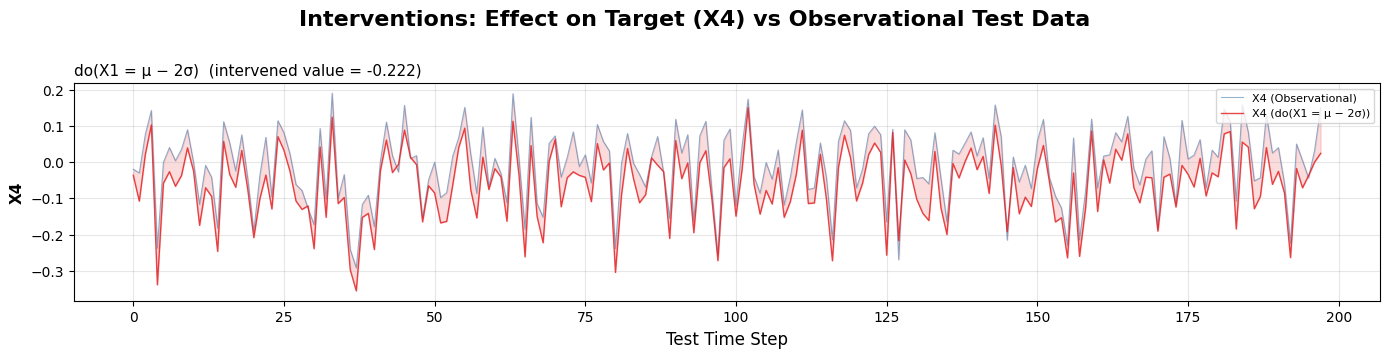


Intervention                Obs Mean   Int Mean     Δ Mean    Obs Std    Int Std
--------------------------------------------------------------------------------
do(X1 = μ − 2σ)              -0.0080    -0.0612    -0.0533     0.1019     0.0977


In [12]:
# ============================================================
# VISUAL 2: Intervention effects on the target variable
# ============================================================
n_interventions = len(intervention_datasets)
fig, axes = plt.subplots(n_interventions, 1, figsize=(14, 3.5 * n_interventions), sharex=True)
if n_interventions == 1:
    axes = [axes]

fig.suptitle(f'Interventions: Effect on Target ({TARGET_VAR}) vs Observational Test Data',
             fontsize=16, fontweight='bold', y=1.01)

# Get observational test values for comparison
obs_target = test_df_raw[TARGET_VAR].values[MAX_LAG:]  # Skip first max_lag rows (lost to lagging)
obs_time = np.arange(len(obs_target))

interv_colors = plt.cm.Set1.colors

for ax_idx, (label, data) in enumerate(intervention_datasets.items()):
    ax = axes[ax_idx]
    interv_target = data['df_lagged'][f'{TARGET_VAR}_lag0'].values
    interv_var = data['var']
    interv_val = data['value']
    
    # Trim to same length
    min_len = min(len(obs_target), len(interv_target))
    
    # Plot observational
    ax.plot(obs_time[:min_len], obs_target[:min_len],
            color='steelblue', alpha=0.6, linewidth=0.8, label=f'{TARGET_VAR} (Observational)')
    
    # Plot intervened
    ax.plot(obs_time[:min_len], interv_target[:min_len],
            color=interv_colors[ax_idx % len(interv_colors)], alpha=0.8, linewidth=1.0,
            label=f'{TARGET_VAR} ({label})')
    
    # Shade the difference
    ax.fill_between(obs_time[:min_len], obs_target[:min_len], interv_target[:min_len],
                    alpha=0.15, color=interv_colors[ax_idx % len(interv_colors)])
    
    ax.set_ylabel(TARGET_VAR, fontsize=11, fontweight='bold')
    title_val = 'Identity' if interv_val is None else f'{interv_val:.3f}'
    ax.set_title(f'{label}  (intervened value = {title_val})', fontsize=11, loc='left')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Test Time Step', fontsize=12)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'Intervention':<25} {'Obs Mean':>10} {'Int Mean':>10} {'Δ Mean':>10} {'Obs Std':>10} {'Int Std':>10}")
print("-" * 80)
for label, data in intervention_datasets.items():
    obs_vals = test_df_raw[TARGET_VAR].values[MAX_LAG:]
    int_vals = data['df_lagged'][f'{TARGET_VAR}_lag0'].values
    min_len = min(len(obs_vals), len(int_vals))
    print(f"{label:<25} {obs_vals[:min_len].mean():>10.4f} {int_vals[:min_len].mean():>10.4f} "
          f"{int_vals[:min_len].mean() - obs_vals[:min_len].mean():>10.4f} "
          f"{obs_vals[:min_len].std():>10.4f} {int_vals[:min_len].std():>10.4f}")

## 10. Main Evaluation Loop

In [13]:
results = []

# Traditional feature set: all features except the target
trad_features = get_traditional_features(df_lagged, target_col)

# Causal feature set: only parents of the target
causal_features = get_causal_features(parent_map, target_col)

print(f"Target: {target_col}")
print(f"Traditional features ({len(trad_features)}): {trad_features}")
print(f"Causal features ({len(causal_features)}):     {causal_features}")
print()

for name, cfg in model_configs.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # ---- CAUSAL MODEL ----
    causal_models = train_causal_models_ts(train_df, parent_map, name, cfg)
    
    # Test evaluation (causal)
    causal_preds = predict_causal_ts(test_df, parent_map, causal_models, name, what_if=False)
    if target_col in causal_preds.columns:
        mae_c, rmse_c, wape_c = evaluate_metrics(test_df[target_col], causal_preds[target_col])
        results.append(["Causal", name, mae_c, rmse_c, wape_c, "Test", "Observational"])
        print(f"  Causal Test  - MAE: {mae_c:.4f}, RMSE: {rmse_c:.4f}, WAPE: {wape_c:.2f}%")
    
    # ---- TRADITIONAL MODEL ----
    X_train_trad = train_df[trad_features]
    y_train = train_df[target_col]
    trad_model = fit_model(name, cfg, X_train_trad, y_train)
    
    # Test evaluation (traditional)
    X_test_trad = test_df[trad_features]
    y_pred_trad = predict_model(name, trad_model, X_test_trad)
    mae_t, rmse_t, wape_t = evaluate_metrics(test_df[target_col], y_pred_trad)
    results.append(["Traditional", name, mae_t, rmse_t, wape_t, "Test", "Observational"])
    print(f"  Trad   Test  - MAE: {mae_t:.4f}, RMSE: {rmse_t:.4f}, WAPE: {wape_t:.2f}%")
    
    # ---- MULTIPLE INTERVENTIONS ----
    for label, int_data in intervention_datasets.items():
        df_int = int_data['df_lagged']
        
        # Causal intervention evaluation
        causal_preds_int = predict_causal_ts(df_int, parent_map, causal_models, name, what_if=True)
        if target_col in causal_preds_int.columns:
            mae_ci, rmse_ci, wape_ci = evaluate_metrics(
                df_int[target_col], causal_preds_int[target_col]
            )
            results.append(["Causal", name, mae_ci, rmse_ci, wape_ci, "Intervention", label])
        
        # Traditional intervention evaluation
        X_int_trad = df_int[trad_features]
        y_pred_trad_int = predict_model(name, trad_model, X_int_trad)
        mae_ti, rmse_ti, wape_ti = evaluate_metrics(
            df_int[target_col], y_pred_trad_int
        )
        results.append(["Traditional", name, mae_ti, rmse_ti, wape_ti, "Intervention", label])
    
    print(f"  Evaluated {len(intervention_datasets)} interventions.")

print("\n" + "="*60)
print("All models trained and evaluated!")
print("="*60)

Target: X4_lag0
Traditional features (14): ['X1_lag0', 'X1_lag1', 'X1_lag2', 'X2_lag0', 'X2_lag1', 'X2_lag2', 'X3_lag0', 'X3_lag1', 'X3_lag2', 'X4_lag1', 'X4_lag2', 'U_lag0', 'U_lag1', 'U_lag2']
Causal features (1):     ['X1_lag2']


Training: RandomForest
  Causal Test  - MAE: 0.0823, RMSE: 0.1037, WAPE: 101.41%
  Trad   Test  - MAE: 0.0772, RMSE: 0.0987, WAPE: 95.12%
  Evaluated 1 interventions.

Training: LinearRegression
  Causal Test  - MAE: 0.0775, RMSE: 0.0976, WAPE: 95.39%
  Trad   Test  - MAE: 0.0792, RMSE: 0.0993, WAPE: 97.52%
  Evaluated 1 interventions.

Training: MLP
  Causal Test  - MAE: 0.0776, RMSE: 0.0978, WAPE: 95.50%
  Trad   Test  - MAE: 0.0787, RMSE: 0.0986, WAPE: 96.88%
  Evaluated 1 interventions.

Training: XGBoost
  Causal Test  - MAE: 0.0879, RMSE: 0.1092, WAPE: 108.30%
  Trad   Test  - MAE: 0.0805, RMSE: 0.1038, WAPE: 99.13%
  Evaluated 1 interventions.

Training: GAM
  Causal Test  - MAE: 0.0773, RMSE: 0.0981, WAPE: 95.23%
  Trad   Test  - MAE: 0.0870, RMSE:

## 11. Results Tables

In [14]:
# Create results DataFrame
results_df = pd.DataFrame(
    results, 
    columns=["Model_Type", "Algorithm", "MAE", "RMSE", "WAPE", "Task", "Intervention"]
)

# Add experiment info
results_df["experiment"] = f"ts_vars{N_VARS}_lag{MAX_LAG}_gaussian"

print("Full Results:")
results_df

Full Results:


,Model_Type,Algorithm,MAE,RMSE,WAPE,Task,Intervention,experiment
0,Causal,RandomForest,0.082348,0.103661,101.406008,Test,Observational,ts_vars4_lag2_gaussian
1,Traditional,RandomForest,0.077246,0.098689,95.123761,Test,Observational,ts_vars4_lag2_gaussian
2,Causal,RandomForest,0.077343,0.100349,88.042424,Intervention,do(X1 = μ − 2σ),ts_vars4_lag2_gaussian
3,Traditional,RandomForest,0.081090,0.105236,92.308496,Intervention,do(X1 = μ − 2σ),ts_vars4_lag2_gaussian
4,Causal,LinearRegression,0.077461,0.097648,95.387677,Test,Observational,ts_vars4_lag2_gaussian
5,Traditional,LinearRegression,0.079190,0.099277,97.517696,Test,Observational,ts_vars4_lag2_gaussian
6,Causal,LinearRegression,0.077622,0.098198,88.360139,Intervention,do(X1 = μ − 2σ),ts_vars4_lag2_gaussian
7,Traditional,LinearRegression,0.079487,0.100470,90.482879,Intervention,do(X1 = μ − 2σ),ts_vars4_lag2_gaussian
8,Causal,MLP,0.077550,0.097759,95.498000,Test,Observational,ts_vars4_lag2_gaussian
9,Traditional,MLP,0.078671,0.098588,96.878327,Test,Observational,ts_vars4_lag2_gaussian


In [15]:
# ============================================================
# TABLE 1: Test Set Results
# ============================================================
test_results = results_df[results_df["Task"] == "Test"].copy()
test_results = test_results.sort_values([ "MAE"]).reset_index(drop=True)
test_results = test_results[["Model_Type", "Algorithm", "MAE", "RMSE", "WAPE"]]

print("=" * 70)
print("TABLE 1: TEST SET PERFORMANCE")
print(f"Config: n_vars={N_VARS}, max_lag={MAX_LAG}, target={TARGET_VAR}")
print("=" * 70)
test_results

TABLE 1: TEST SET PERFORMANCE
Config: n_vars=4, max_lag=2, target=X4


,Model_Type,Algorithm,MAE,RMSE,WAPE
0,Traditional,RandomForest,0.077246,0.098689,95.123761
1,Causal,GAM,0.077330,0.098111,95.227036
2,Causal,LinearRegression,0.077461,0.097648,95.387677
3,Causal,MLP,0.077550,0.097759,95.498000
4,Traditional,MLP,0.078671,0.098588,96.878327
5,Traditional,LinearRegression,0.079190,0.099277,97.517696
6,Traditional,XGBoost,0.080503,0.103752,99.133636
7,Causal,RandomForest,0.082348,0.103661,101.406008
8,Traditional,GAM,0.086966,0.111624,107.092413
9,Causal,XGBoost,0.087945,0.109239,108.298198


In [16]:
# ============================================================
# TABLE 2: Intervention Results (all interventions)
# ============================================================
inter_results = results_df[results_df["Task"] == "Intervention"].copy()
inter_results = inter_results.sort_values(["Intervention", "MAE"]).reset_index(drop=True)
inter_results_display = inter_results[["Intervention", "Model_Type", "Algorithm", "MAE", "RMSE", "WAPE"]]

print("=" * 80)
print("TABLE 2: INTERVENTION PERFORMANCE (All Interventions)")
print(f"Config: n_vars={N_VARS}, max_lag={MAX_LAG}, target={TARGET_VAR}")
print("=" * 80)
inter_results_display

TABLE 2: INTERVENTION PERFORMANCE (All Interventions)
Config: n_vars=4, max_lag=2, target=X4


,Intervention,Model_Type,Algorithm,MAE,RMSE,WAPE
0,do(X1 = μ − 2σ),Causal,RandomForest,0.077343,0.100349,88.042424
1,do(X1 = μ − 2σ),Causal,MLP,0.077611,0.098220,88.347431
2,do(X1 = μ − 2σ),Causal,LinearRegression,0.077622,0.098198,88.360139
3,do(X1 = μ − 2σ),Causal,GAM,0.077716,0.098027,88.467084
4,do(X1 = μ − 2σ),Causal,XGBoost,0.079001,0.097848,89.929433
5,do(X1 = μ − 2σ),Traditional,LinearRegression,0.079487,0.100470,90.482879
6,do(X1 = μ − 2σ),Traditional,RandomForest,0.081090,0.105236,92.308496
7,do(X1 = μ − 2σ),Traditional,MLP,0.082086,0.101202,93.441255
8,do(X1 = μ − 2σ),Traditional,GAM,0.091937,0.116343,104.655058
9,do(X1 = μ − 2σ),Traditional,XGBoost,0.092178,0.114421,104.929464


In [17]:
# ============================================================
# Summary: Average MAE across all interventions
# ============================================================
print("\n" + "=" * 70)
print("SUMMARY: Average MAE by Model Type and Task")
print("=" * 70)

summary = results_df.groupby(["Task", "Model_Type"])["MAE"].mean().unstack()
print(summary)
print()

# Per-intervention breakdown
print("\n" + "=" * 70)
print("SUMMARY: Average MAE by Intervention × Model Type")
print("=" * 70)
inter_summary = inter_results.groupby(["Intervention", "Model_Type"])["MAE"].mean().unstack()
print(inter_summary)
print()
print("Lower MAE is better. Causal models should especially shine on Interventions.")


SUMMARY: Average MAE by Model Type and Task
Model_Type      Causal  Traditional
Task                               
Intervention  0.077858     0.085355
Test          0.080527     0.080515


SUMMARY: Average MAE by Intervention × Model Type
Model_Type         Causal  Traditional
Intervention                          
do(X1 = μ − 2σ)  0.077858     0.085355

Lower MAE is better. Causal models should especially shine on Interventions.
